# Health Insurance — Customer Clustering Analysis

## Business Problem

HealthSecure, a health insurance provider, is facing increasing medical costs.  
The company needs to better understand its customer base in order to design more
efficient pricing strategies and reduce financial risk.

The central question of this analysis is:

**Can we identify distinct customer profiles that explain differences in medical expenses and support a more accurate premium pricing strategy?**

---

## Project Objectives

This project aims to:

- Identify distinct customer segments using clustering techniques
- Understand the characteristics of each segment
- Evaluate how medical expenses differ between groups
- Support pricing strategy decisions based on customer risk profiles

---

## Analytical Approach

The analysis follows the steps below:

1. Data loading and validation  
2. Data preparation and feature selection  
3. Standardization of variables  
4. Determination of optimal number of clusters (Elbow Method)  
5. K-Means clustering model  
6. Cluster profiling and interpretation  
7. Business insights and pricing strategy recommendations

## Data Loading

In [1]:
# =========================================
# Libraries
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

import joblib


In [2]:
# =========================================
# Notebook configuration
# =========================================

RANDOM_STATE = 1

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [3]:
# =========================================
# Data loading
# =========================================
base_health_insurance_df = pd.read_csv("../data/base_health_insurance.csv",sep = ";")
display(base_health_insurance_df.head())            

,age,gender,bmi,children,discount_eligibility,region,expenses,premium
0,19,female,"24,1",0,yes,south,"1483,21","1744,95"
1,18,male,"23,5",1,no,southeast,"2237,61","2632,48"
2,28,male,33,3,no,southeast,"2046,09","2728,12"
3,33,male,"23,3",0,no,midwest,"2331,69","2743,17"
4,32,male,"23,4",0,no,midwest,"1942,5","2285,3"


In [4]:
# =========================================
# Data validation
# =========================================

print(base_health_insurance_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   age                   1338 non-null   int64
 1   gender                1338 non-null   str  
 2   bmi                   1338 non-null   str  
 3   children              1338 non-null   int64
 4   discount_eligibility  1338 non-null   str  
 5   region                1338 non-null   str  
 6   expenses              1338 non-null   str  
 7   premium               1338 non-null   str  
dtypes: int64(2), str(6)
memory usage: 83.8 KB
None


In [5]:
# =========================================
# Data adjustment
# bmi must be a float
# Discount eligibility must be binary
# =========================================
base_health_insurance_df["bmi"] = base_health_insurance_df["bmi"].str.replace(",", ".").astype(float)

base_health_insurance_df["discount_eligibility_binary"] = np.where(
    base_health_insurance_df["discount_eligibility"]=="yes",1,0)

display(base_health_insurance_df["discount_eligibility"].unique())

print(base_health_insurance_df.info())


<StringArray>
['yes', 'no']
Length: 2, dtype: str

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          1338 non-null   int64  
 1   gender                       1338 non-null   str    
 2   bmi                          1338 non-null   float64
 3   children                     1338 non-null   int64  
 4   discount_eligibility         1338 non-null   str    
 5   region                       1338 non-null   str    
 6   expenses                     1338 non-null   str    
 7   premium                      1338 non-null   str    
 8   discount_eligibility_binary  1338 non-null   int64  
dtypes: float64(1), int64(3), str(5)
memory usage: 94.2 KB
None


## Feature Selection

For the clustering process, the following variables were selected:

- Age  
- BMI  
- Number of children  
- Discount eligibility (to be encoded as binary: 0 = no, 1 = yes)

These variables were chosen because they represent key demographic and behavioral factors that directly influence health risk and, consequently, medical costs.

Age and BMI are strong indicators of health condition and risk exposure.  
The number of children may impact healthcare usage and financial pressure on insurance plans.  
Discount eligibility reflects policy-related segmentation that may influence pricing and customer grouping.

Together, these variables provide a meaningful representation of customer profiles, enabling the identification of distinct clusters for pricing strategy optimization.


In [6]:
# =========================================
# Selecting columns for clustering
# =========================================

cluster_columns = ["age", "bmi", "children", "discount_eligibility_binary"]
cluster_df = base_health_insurance_df[cluster_columns]

display(cluster_df.head())

,age,bmi,children,discount_eligibility_binary
0,19,24.1,0,1
1,18,23.5,1,0
2,28,33.0,3,0
3,33,23.3,0,0
4,32,23.4,0,0


## Data Standardization

Before clustering, all variables must be on the same scale.  
Without standardization, variables with larger ranges (like age) would dominate the distance calculations used by K-Means, producing biased clusters.

StandardScaler transforms each variable to have mean = 0 and standard deviation = 1.

In [7]:
# =========================================
# Data standardization
# =========================================

scaler = StandardScaler() #starting the scaler object
cluster_scaled = scaler.fit_transform(cluster_df)
cluster_scaled_df = pd.DataFrame(cluster_scaled, columns=cluster_df.columns)

display(cluster_scaled_df.head())

,age,bmi,children,discount_eligibility_binary
0,-1.438764,-0.651784,-0.908614,1.970587
1,-1.509965,-0.746074,-0.078767,-0.507463
2,-0.797954,0.746849,1.580926,-0.507463
3,-0.441948,-0.777504,-0.908614,-0.507463
4,-0.513149,-0.761789,-0.908614,-0.507463


## Elbow Method

To apply K-Means, we need to decide how many clusters (K) best represent the data.
The Elbow Method helps by running K-Means for a range of K values and measuring the inertia —
the sum of squared distances between each point and its assigned centroid.

As K increases, inertia always decreases. The optimal K is the point where the reduction
starts to flatten, forming an "elbow" in the curve. Beyond that point, adding more clusters
brings diminishing returns.


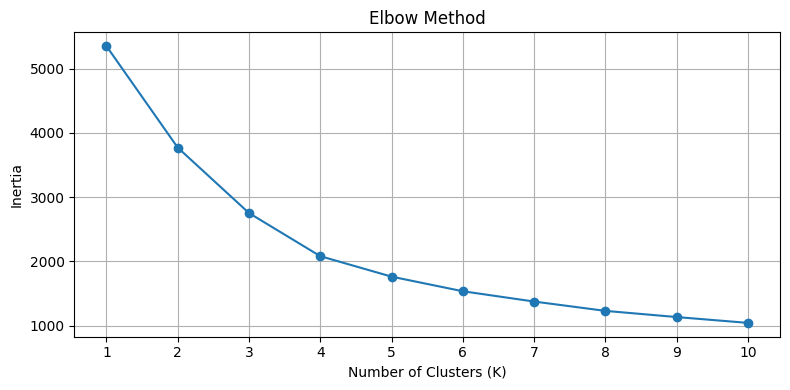

In [8]:
# =========================================
# Elbow Method
# =========================================

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
n_clusters = range(1, 11) # testing K from 1 to 10

for n in n_clusters:
    kmeans_model = KMeans(n_clusters=n, random_state=RANDOM_STATE, n_init=10) # initializing KMeans for each K
    kmeans_model.fit(cluster_scaled_df) # fitting (training) standardized data
    inertia.append(kmeans_model.inertia_) # storing inertia for each K

plt.figure(figsize=(8, 4))
plt.plot(n_clusters, inertia, marker='o') # plotting inertia vs K
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(n_clusters)
plt.grid(True)
plt.tight_layout()
plt.show()


## Choosing the Number of Clusters

After applying the Elbow Method, the inertia curve was plotted for K values ranging from 2 to 10.

The curve shows a clear inflection point at K=4, where the rate of inertia reduction slows significantly. Beyond this point, adding more clusters brings diminishing returns in compactness.

Therefore, K=4 was selected as the optimal number of clusters for this analysis.


## K-Means Clustering

With the optimal number of clusters defined as K=4, the K-Means algorithm is applied to the standardized dataset.

K-Means works by iteratively assigning each observation to the nearest centroid and recalculating centroids until convergence. The result is a set of cluster labels, one for each customer in the dataset.

These labels will be used in the next step to profile each cluster and extract business insights.



In [9]:
# =========================================
# K-Means Clustering
# =========================================

kmeans_model = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10) # training K-Means with 4 clusters
kmeans_model.fit(cluster_scaled_df) # fitting on standardized data

base_health_insurance_df['cluster'] = kmeans_model.labels_ # assigning cluster labels to the original dataframe


## Cluster Assignment

Each customer in the dataset has now been assigned to one of the four clusters identified by the K-Means algorithm.

The cluster label is stored in a new column called `cluster` in the original dataframe, allowing us to analyze customer profiles alongside all original variables such as age, bmi, expenses, and premium.


In [10]:
display(base_health_insurance_df.head())


,age,gender,bmi,children,discount_eligibility,region,expenses,premium,discount_eligibility_binary,cluster
0,19,female,24.1,0,yes,south,"1483,21","1744,95",1,1
1,18,male,23.5,1,no,southeast,"2237,61","2632,48",0,2
2,28,male,33.0,3,no,southeast,"2046,09","2728,12",0,3
3,33,male,23.3,0,no,midwest,"2331,69","2743,17",0,2
4,32,male,23.4,0,no,midwest,"1942,5","2285,3",0,2


## Exporting the Clustered Dataset

With the cluster labels assigned to each customer, the updated dataset is exported as a CSV file for future use, reporting, or integration with other systems.

Exporting the data at this stage ensures that the clustering results are preserved independently of the notebook, making them available for business analysis and decision-making.


In [ ]:
# =========================================
# Exporting the Clustered Dataset
# =========================================

base_health_insurance_df.to_csv('../data/base_health_insurance_clustered.csv', index=False) # exporting updated dataframe with cluster column
